In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

In [2]:
# ===== RUTAS =====
PROJECT_ROOT = Path.cwd().resolve().parents[3]

NOMBRE_SCALED = "BCCC17__scaled__v1"
NOMBRE_PCA = "BCCC17__pca__v1"

RUTA_SCALED = PROJECT_ROOT / "02_datasets" / "processed_analisis_estadistico" / NOMBRE_SCALED
RUTA_SALIDA = PROJECT_ROOT / "02_datasets" / "processed_analisis_estadistico" / NOMBRE_PCA

# ===== ARCHIVOS =====
TRAIN_FILE = f"{NOMBRE_SCALED}__train.csv"

PLOT_FILE = "pca_variance_plot.png"
REPORT_FILE = f"{NOMBRE_PCA}_report.json"

# ===== CONFIG =====
LABEL_COL = "LABEL"
VARIANCE_THRESHOLD = 0.95

In [3]:
print("Ruta entrada:", RUTA_SCALED)
print("Ruta salida:", RUTA_SALIDA)

Ruta entrada: /LUSTRE/home/inginf/u32902122/TFG/02_datasets/processed_analisis_estadistico/BCCC17__scaled__v1
Ruta salida: /LUSTRE/home/inginf/u32902122/TFG/02_datasets/processed_analisis_estadistico/BCCC17__pca__v1


In [4]:
train_path = RUTA_SCALED / TRAIN_FILE

if not train_path.exists():
    raise FileNotFoundError(train_path)

df = pd.read_csv(train_path)

print("Shape:", df.shape)

Shape: (1947002, 65)


In [5]:
X = df.drop(columns=[LABEL_COL])

print("Número de features:", X.shape[1])

Número de features: 64


In [6]:
pca = PCA()
pca.fit(X)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

In [7]:
k = np.argmax(cumulative_variance >= VARIANCE_THRESHOLD) + 1

print(f"k para {VARIANCE_THRESHOLD*100}% de varianza:", k)

k para 95.0% de varianza: 1


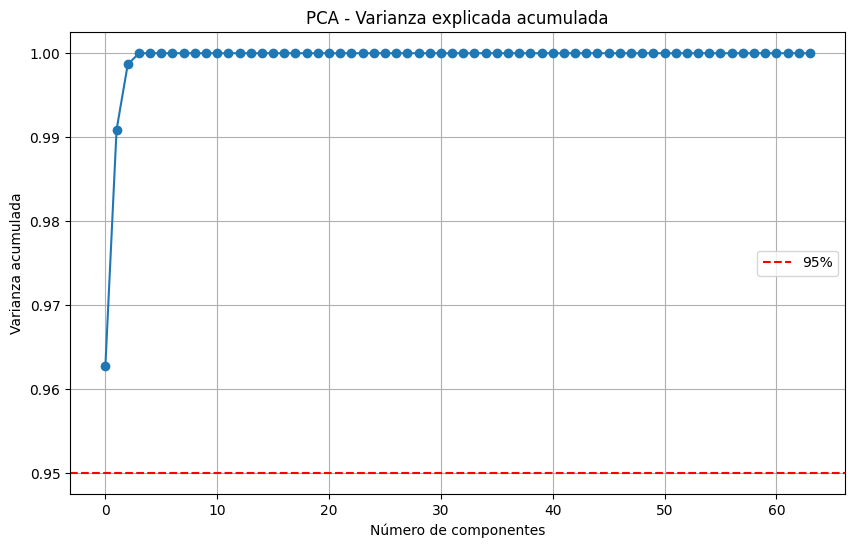

In [8]:
plt.figure(figsize=(10, 6))

plt.plot(cumulative_variance, marker='o')
plt.axhline(y=VARIANCE_THRESHOLD, color='r', linestyle='--', label='95%')

plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.title("PCA - Varianza explicada acumulada")
plt.grid(True)
plt.legend()

plt.show()

In [9]:
RUTA_SALIDA.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 6))
plt.plot(cumulative_variance)
plt.axhline(y=VARIANCE_THRESHOLD, linestyle='--')

plt.savefig(RUTA_SALIDA / PLOT_FILE)
plt.close()

In [10]:
if k < 5:
    interpretacion = "Alta redundancia en las características"
elif k > 30:
    interpretacion = "Alta complejidad del espacio → justifica uso de LLM"
else:
    interpretacion = "Complejidad moderada del dataset"

print("Interpretación:", interpretacion)

Interpretación: Alta redundancia en las características


In [11]:
reporte = {
    "dataset": NOMBRE_SCALED,
    "num_features_original": int(X.shape[1]),
    "variance_threshold": VARIANCE_THRESHOLD,
    "k_components_95_variance": int(k),
    "explained_variance_first_10": explained_variance[:10].tolist(),
    "interpretation": interpretacion
}

with open(RUTA_SALIDA / REPORT_FILE, "w") as f:
    json.dump(reporte, f, indent=2)

print("Reporte guardado")

Reporte guardado


In [12]:
print("========== PCA RESULT ==========")
print("Features originales:", X.shape[1])
print("k (95% varianza):", k)
print("Interpretación:", interpretacion)
print("===============================")

========== PCA RESULT ==========
Features originales: 64
k (95% varianza): 1
Interpretación: Alta redundancia en las características


In [13]:
print("========== ANÁLISIS DE COMPONENTES PCA ==========\n")

import pandas as pd

# Crear DataFrame con las componentes
componentes = pd.DataFrame(
    pca.components_,
    columns=X.columns
)

# Número de componentes a analizar (puedes cambiarlo)
NUM_COMPONENTES = 5

for i in range(NUM_COMPONENTES):
    print(f"--- COMPONENTE PRINCIPAL {i+1} ---")
    
    # Ordenar por importancia (valor absoluto)
    top_features = componentes.iloc[i].abs().sort_values(ascending=False)
    
    # Mostrar top 10
    print("Top 10 variables más importantes:")
    display(top_features.head(10))
    
    print("\nValores con signo (para interpretación):")
    display(componentes.iloc[i][top_features.head(10).index])
    
    print("\n")

print("===============================================")

========== ANÁLISIS DE COMPONENTES PCA ==========

--- COMPONENTE PRINCIPAL 1 ---
Top 10 variables más importantes:


PACKETS_IAT_MEAN              9.997631e-01
BWD_PACKETS_IAT_MEAN          1.855188e-02
AVG_BWD_BULK_RATE             1.134932e-02
AVG_FWD_BULK_RATE             8.296697e-04
AVG_BWD_BYTES_PER_BULK        1.240926e-05
FWD_PAYLOAD_BYTES_VARIANCE    1.924139e-06
FWD_BYTES_RATE                8.687223e-07
SUBFLOW_FWD_BYTES             5.691441e-07
FWD_BULK_TOTAL_SIZE           5.362743e-07
AVG_FWD_BYTES_PER_BULK        4.028188e-07
Name: 0, dtype: float64


Valores con signo (para interpretación):


PACKETS_IAT_MEAN              9.997631e-01
BWD_PACKETS_IAT_MEAN          1.855188e-02
AVG_BWD_BULK_RATE            -1.134932e-02
AVG_FWD_BULK_RATE            -8.296697e-04
AVG_BWD_BYTES_PER_BULK       -1.240926e-05
FWD_PAYLOAD_BYTES_VARIANCE   -1.924139e-06
FWD_BYTES_RATE               -8.687223e-07
SUBFLOW_FWD_BYTES            -5.691441e-07
FWD_BULK_TOTAL_SIZE          -5.362743e-07
AVG_FWD_BYTES_PER_BULK       -4.028188e-07
Name: 0, dtype: float64



--- COMPONENTE PRINCIPAL 2 ---
Top 10 variables más importantes:


...

AVG_FWD_BULK_RATE             0.999984
BWD_PACKETS_IAT_MEAN          0.004373
AVG_BWD_BULK_RATE             0.003401
PACKETS_IAT_MEAN              0.000787
FWD_BYTES_RATE                0.000267
FWD_PAYLOAD_BYTES_VARIANCE    0.000111
FWD_BULK_TOTAL_SIZE           0.000075
AVG_FWD_BYTES_PER_BULK        0.000067
BYTES_RATE                    0.000049
FWD_PACKETS_RATE              0.000037
Name: 3, dtype: float64



--- COMPONENTE PRINCIPAL 5 ---
Top 10 variables más importantes:


AVG_BWD_BYTES_PER_BULK        0.999988
PACKETS_COUNT                 0.003553
SUBFLOW_FWD_PACKETS           0.003304
SUBFLOW_FWD_BYTES             0.000913
FWD_BULK_TOTAL_SIZE           0.000276
AVG_BWD_BULK_RATE             0.000248
FWD_PAYLOAD_BYTES_VARIANCE    0.000192
DURATION                      0.000160
PSH_FLAG_COUNTS               0.000159
FWD_BYTES_RATE                0.000147
Name: 4, dtype: float64


Valores con signo (para interpretación):


AVG_BWD_BYTES_PER_BULK        0.999988
PACKETS_COUNT                 0.003553
SUBFLOW_FWD_PACKETS           0.003304
SUBFLOW_FWD_BYTES             0.000913
FWD_BULK_TOTAL_SIZE           0.000276
AVG_BWD_BULK_RATE            -0.000248
FWD_PAYLOAD_BYTES_VARIANCE   -0.000192
DURATION                      0.000160
PSH_FLAG_COUNTS               0.000159
FWD_BYTES_RATE               -0.000147
Name: 4, dtype: float64

In [14]:
print("========== DIAGNÓSTICO PCA ==========\n")

# 1. Shape
print("Shape de X:", X.shape)
print()

# 2. Columnas
print("Número de columnas:", len(X.columns))
print("Primeras 20 columnas:")
print(X.columns[:20])
print()

# 3. ¿Está LABEL dentro?
print("¿LABEL está en X?:", "LABEL" in X.columns)
print()

# 4. Tipos de datos
print("Tipos de datos:")
print(X.dtypes.value_counts())
print()

# 5. Columnas no numéricas (MUY IMPORTANTE)
non_numeric = X.select_dtypes(exclude=["int64", "float64"]).columns
print("Columnas NO numéricas:", list(non_numeric))
print()

# 6. Estadísticas básicas
print("Estadísticas básicas (primeras columnas):")
print(X.describe().iloc[:, :10])
print()

# 7. Desviación estándar (detección de columnas constantes)
stds = X.std()
print("Columnas con std ≈ 0:")
print(stds[stds < 1e-6].sort_values())
print()

# 8. Varianza explicada PCA
from sklearn.decomposition import PCA
import numpy as np

pca = PCA()
pca.fit(X)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print("Primeras 10 varianzas explicadas:")
print(explained[:10])
print()

print("Varianza acumulada primeras 10:")
print(cumulative[:10])
print()

# 9. Resultado k
k = np.argmax(cumulative >= 0.95) + 1
print("k calculado:", k)

print("\n====================================")

========== DIAGNÓSTICO PCA ==========

Shape de X: (1947002, 64)

Número de columnas: 64
Primeras 20 columnas:
Index(['TIMESTAMP', 'DST_PORT', 'DURATION', 'PACKETS_COUNT',
       'FWD_TOTAL_PAYLOAD_BYTES', 'PAYLOAD_BYTES_MAX', 'PAYLOAD_BYTES_MIN',
       'PAYLOAD_BYTES_MEAN', 'PAYLOAD_BYTES_VARIANCE',
       'FWD_PAYLOAD_BYTES_VARIANCE', 'MAX_HEADER_BYTES', 'MIN_HEADER_BYTES',
       'STD_HEADER_BYTES', 'FWD_MAX_HEADER_BYTES', 'FWD_MIN_HEADER_BYTES',
       'FWD_STD_HEADER_BYTES', 'BWD_MAX_HEADER_BYTES', 'BWD_STD_HEADER_BYTES',
       'FWD_AVG_SEGMENT_SIZE', 'FWD_INIT_WIN_BYTES'],
      dtype='str')

¿LABEL está en X?: False

Tipos de datos:
float64    63
bool        1
Name: count, dtype: int64

Columnas NO numéricas: ['PROTOCOL_TCP']

Estadísticas básicas (primeras columnas):


          TIMESTAMP      DST_PORT      DURATION  PACKETS_COUNT  \
count  1.947002e+06  1.947002e+06  1.947002e+06   1.947002e+06   
mean   2.090619e-03  1.634646e+01  4.392006e+01   1.903263e+00   
std    5.744580e-01  4.190287e+01  3.385631e+02   4.316446e+02   
min   -9.777258e-01 -2.025641e-01 -6.466939e-02  -3.333333e-01   
25%   -4.997776e-01 -6.923077e-02 -6.455077e-02  -2.222222e-01   
50%    0.000000e+00  0.000000e+00  0.000000e+00   0.000000e+00   
75%    5.002224e-01  9.307692e-01  9.354492e-01   7.777778e-01   
max    1.000477e+00  1.678282e+02  8.288964e+04   2.740400e+05   

       FWD_TOTAL_PAYLOAD_BYTES  PAYLOAD_BYTES_MAX  PAYLOAD_BYTES_MIN  \
count             1.947002e+06       1.947002e+06       1.947002e+06   
mean              1.669121e+00       9.915684e-01       4.241265e-01   
std               2.954717e+01       2.216835e+00       9.912970e-01   
min              -2.510121e-01      -9.381443e-02       0.000000e+00   
25%              -2.510121e-01      -9.381443

Columnas con std ≈ 0:
Series([], dtype: float64)



Primeras 10 varianzas explicadas:
[9.62739515e-01 2.81509472e-02 7.77012716e-03 1.33926432e-03
 1.38851244e-07 2.97273152e-09 1.89928039e-09 1.74093282e-09
 2.12511249e-10 1.69587452e-10]

Varianza acumulada primeras 10:
[0.96273952 0.99089046 0.99866059 0.99999985 0.99999999 1.
 1.         1.         1.         1.        ]

k calculado: 1

